In [1]:
%matplotlib widget

In [2]:
import matplotlib.pyplot as plt

In [37]:
import pytest
import pathlib
import numpy as np
import libertem.api as lt
from libertem.udf.raw import PickUDF
from libertem.udf.logsum import LogsumUDF
from cbed_simulation.udf import build_udf_ds
from cbed_simulation.crystal_orientation import ExperimentInformation, OrientedPhase, IndexedPeaks, LatticeMultipliers
from cbed_simulation.frame_builder import FrameParameters

from libertem_blobfinder.common import patterns, correlation
from libertem_blobfinder.udf import refinement, utils
import libertem_blobfinder.common.fullmatch as fm
import libertem_blobfinder.base.masks as masks

ROOT_PATH = pathlib.Path(".").absolute()

In [4]:
ROOT_PATH

PosixPath('/cachedata/alex/source/modules/LiberTEM-blobfinder/examples')

In [5]:
tmp_path = pathlib.Path("/cachedata/alex/tmp/cbeds")

In [6]:
ctx = lt.Context()

/home/alex/miniforge3/envs/libertem/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34227 instead
  warnings.warn(


# Simulate example data

In [94]:
dim = 17

multips = np.ndarray((dim, dim), dtype=object)

for y, yv in enumerate(np.linspace(0.97, 1.03, num=dim, endpoint=True)):
    for x, xv in enumerate(np.linspace(0.97, 1.03, num=dim, endpoint=True)):
        multips[y, x] = LatticeMultipliers(a=xv, b=yv)

In [53]:
experiment = ExperimentInformation(
    frame_shape=(256, 256),
    transmitted_centre_px=complex(128, 128),
    radius_px=12,
    pattern_scale_factor=100.,  # pixels / Å-1
)
frame_params = FrameParameters()
phase = OrientedPhase.from_cif(ROOT_PATH / "Si.cif")

out_path = tmp_path / "frames.npy"
udf, ds = build_udf_ds(
    out_path,
    (dim, dim),
    ctx,
    phase,
    experiment,
    frame_parameters=frame_params,
    lattice_mod=multips,
)
res = ctx.run_udf(ds, udf)
assert out_path.is_file()
frames = np.load(out_path)
peaks: IndexedPeaks = res["peak_positions"].data[0]

In [54]:
ds_frames = ctx.load("npy", out_path)

In [55]:
res = ctx.run_udf(dataset=ds_frames, udf=PickUDF(), roi=ds_frames.roi[:])

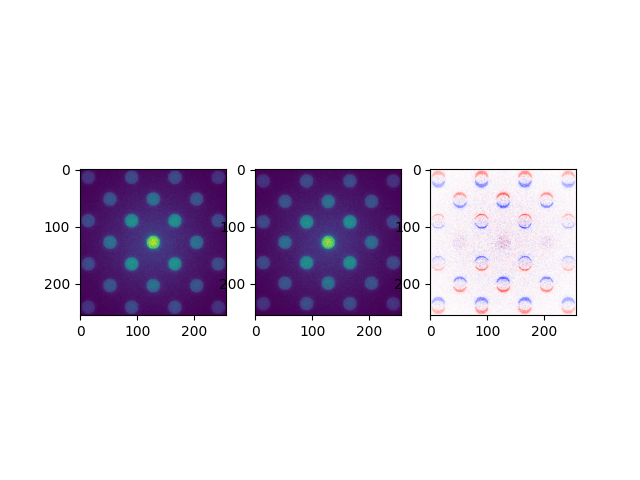

In [56]:
fig, ax = plt.subplots(ncols=3)
ax[0].imshow(res['intensity'].data[0])
ax[1].imshow(res['intensity'].data[16*16 - 1])
ax[2].imshow(res['intensity'].data[0] - res['intensity'].data[16*16 - 1], cmap='bwr')

In [80]:
logsum_res = ctx.run_udf(dataset=ds_frames, udf=LogsumUDF())
logsum = logsum_res['logsum'].data

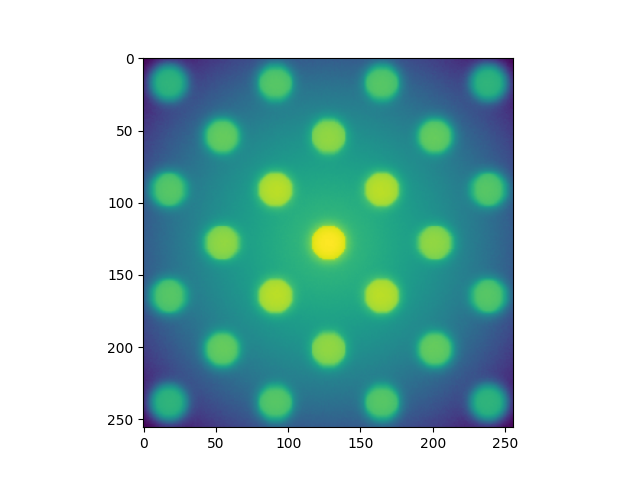

In [81]:
fig, ax = plt.subplots()
ax.imshow(logsum)

# Disk finding

In [58]:
matcher = fm.FullMatcher(tolerance=7)

## Get candidate peaks (initial lattice)

From the `logsum`, we can find candidate positions for the CBED disks.

In [82]:
match_pattern = patterns.BackgroundSubtraction(
    radius=experiment.radius_px, search=experiment.radius_px*1.2, radius_outer=experiment.radius_px*1.2
)

# Find peaks in the logsum frame
found_peaks = correlation.get_peaks(sum_result=logsum, match_pattern=match_pattern, num_peaks=16)

# Find lattice match for peaks from scratch
# This doesn't take into account the 3D crystal structure of the sample,
# but works purely within the 2D geometry of the detector
(matches, unmatched, weak) = matcher.full_match(found_peaks)

In [61]:
matches

## Refine match on whole dataset

From the `zero`, `a`, and `b` of the candidate match, we can run a position refinement on the whole data set. This will give us the lattice vectors `a` and `b`.

In [83]:
m = matches[0]
# Refine the lattice parameters for each frame
match, indices = refinement.run_refine(
    ctx=ctx,
    dataset=ds_frames,
    zero=m.zero,
    a=m.a,
    b=m.b,
    indices=np.mgrid[-2:3, -2:3],  # maximum grid vector
    matcher=matcher,
    match_pattern=match_pattern,
    progress=True,
)

Partitions 0/24, Frames:   0%|          | 0/289 [00:00<?, ?it/s]

In [84]:
match['a']

<BufferWrapper kind=nav dtype=float32 extra_shape=(2,)>

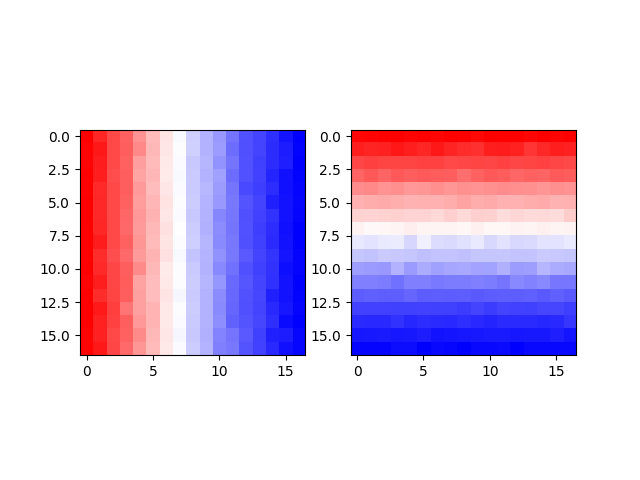

In [85]:
fig, ax = plt.subplots(ncols=2)
ax[0].imshow(np.linalg.norm(match['a'].data, axis=-1), cmap='bwr')
ax[1].imshow(np.linalg.norm(match['b'].data, axis=-1), cmap='bwr')

# Strain

Calculate the strain from lattice vectors and an unstrained reference lattice vector.

In [86]:
from cbed_simulation.strain_decomposition import compute_strain_large_def
from cbed_simulation.utils import to_complex¶

In [96]:
# strain calculations use complex values, so we need to convert all the latice vectors here:
g1 = to_complex(match['a'].data)
g2 = to_complex(match['b'].data)

In [97]:
strain = compute_strain_large_def(
    g1=g1,
    g2=g2,

    # single reference lattice vector from the middle of the dataset:
    g1_ref=g1[8,8],
    g2_ref=g2[8,8],
)

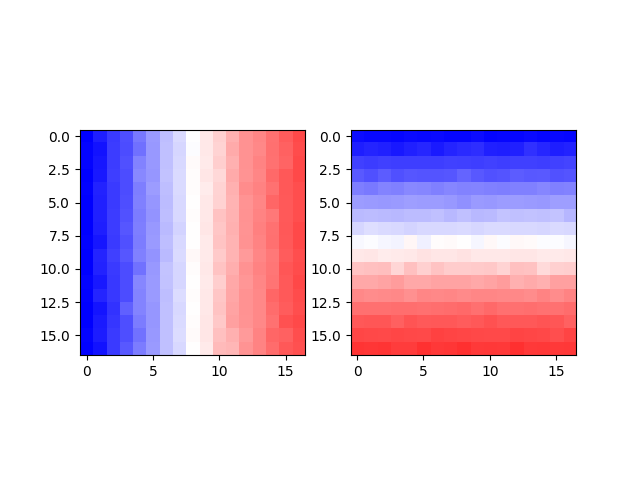

In [98]:
fig, ax = plt.subplots(ncols=2)
vmax = strain.strain_limit()
ax[0].imshow(strain.e_xx, cmap='bwr', vmin=-vmax, vmax=vmax)
ax[1].imshow(strain.e_yy, cmap='bwr', vmin=-vmax, vmax=vmax)